# EDA — Technical Support Dataset (dataset de teste)

Exploração do dataset `data/testing_datasets/Technical Support Dataset.csv`: tickets de suporte técnico com SLA, tempos de resposta/resolução, agente, canal e geolocalização por país. É um dataset separado do pipeline principal (`customer_support_tickets.csv`) — schema, granularidade e finalidade diferentes — por isso mora em `data/testing_datasets/` em vez de `data/raw/`, e este notebook não depende de `make data` nem dos splits em `data/processed/`.

**Objetivo:** avaliar a qualidade do dataset (consistência de categorias, nulos, coerência temporal entre os campos de SLA) antes de decidir se e como usá-lo.

**Índice**
1. Carregamento dos dados
2. Estrutura básica e granularidade
3. Valores ausentes
4. Distribuição de `Status`, `Priority`, `Source` e `Support Level`
5. Qualidade das colunas categóricas: duplicatas de categoria e redundância
6. Consistência temporal: ordem cronológica dos timestamps
7. Consistência das colunas de SLA vs. os timestamps reais
8. Geolocalização: granularidade real de `Latitude`/`Longitude`
9. Resumo dos principais achados

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from customer_support_analytics.config import DATA_DIR

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

# Paleta categórica com ordem fixa (identidade da série nunca é ciclada por rank/posição)
CATEGORICAL_PALETTE = [
    "#2a78d6",  # blue
    "#eb6834",  # orange
    "#1baf7a",  # aqua
    "#eda100",  # yellow
    "#e87ba4",  # magenta
    "#008300",  # green
    "#4a3aa7",  # violet
    "#e34948",  # red
]
BLUE = CATEGORICAL_PALETTE[0]

plt.rcParams.update({
    "axes.prop_cycle": plt.cycler(color=CATEGORICAL_PALETTE),
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#0b0b0b",
    "axes.titlecolor": "#0b0b0b",
    "text.color": "#0b0b0b",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
    "grid.color": "#e1e0d9",
    "axes.grid": True,
    "grid.linewidth": 0.6,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "font.size": 11,
})

DATASET_PATH = DATA_DIR / "testing_datasets" / "Technical Support Dataset.csv"

STATUS_ORDER = ["Open", "In progress", "Resolved", "Closed"]
PRIORITY_ORDER = ["Low", "Medium", "High"]
SOURCE_ORDER = ["Email", "Chat", "Phone"]
SUPPORT_LEVEL_ORDER = ["Tier 1", "Tier 2"]

DATE_COLS = [
    "Created time",
    "Expected SLA to first response",
    "Expected SLA to resolve",
    "First response time",
    "Resolution time",
    "Close time",
]

2026-08-21 19:20:56.012 | INFO     | customer_support_analytics.config:<module>:11 - PROJ_ROOT path is: C:\Users\Micro\Documents\GitHub\estudo_customer_support


## 1. Carregamento dos dados

In [2]:
df = pd.read_csv(DATASET_PATH)
print(f"shape: {df.shape}")
df.head()

shape: (2330, 22)


,Status,Ticket ID,Priority,Source,Topic,Agent Group,Agent Name,Created time,Expected SLA to resolve,Expected SLA to first response,First response time,SLA For first response,Resolution time,SLA For Resolution,Close time,Agent interactions,Survey results,Product group,Support Level,Country,Latitude,Longitude
0,Closed,1012,Low,Email,Feature request,1st line support,Kristos Westoll,2023-01-02 00:58:36,2023-01-04 00:58:36,2023-01-02 01:58:36,2023-01-02 01:03:17.432,Within SLA,2023-01-04 00:31:51.694,Within SLA,2023-01-04 04:02:59.013,1.0,3.0,Custom software development,Tier 1,Republic of Ireland,53.094024,-8.019675
1,In progress,1013,High,Phone,Product setup,2nd line support,Adolpho Messingham,2023-01-02 07:27:25,2023-01-04 07:27:25,2023-01-02 07:29:25,2023-01-02 07:27:43.231,Within SLA,NaN,SLA Violated,NaN,3.0,NaN,Other,Tier 2,Italy,43.036776,12.678565
2,Resolved,1014,Low,Chat,Purchasing and invoicing,1st line support,Bernard Beckley,2023-01-02 06:59:04,2023-01-03 06:59:04,2023-01-02 07:01:04,2023-01-02 06:59:57.471,Within SLA,2023-01-02 22:45:32.974,Within SLA,NaN,2.0,NaN,Custom software development,Tier 1,Austria,47.696472,13.345735
3,Closed,1015,Medium,Email,Pricing and licensing,1st line support,Connor Danielovitch,2023-01-03 03:09:39,2023-01-05 03:09:39,2023-01-03 04:09:39,2023-01-03 07:09:15.835,SLA Violated,2023-01-04 14:32:34.979,Within SLA,2023-01-08 04:24:54.771,10.0,4.0,Ready to use Software,Tier 1,Spain,39.673370,-4.767726
4,Closed,1016,Low,Email,Product setup,1st line support,Kristos Westoll,2023-01-03 00:03:58,2023-01-05 00:03:58,2023-01-03 01:03:58,2023-01-03 00:08:01.684,Within SLA,2023-01-04 12:03:05.986,Within SLA,2023-01-06 06:05:08.637,1.0,2.0,Other,Tier 1,Austria,47.696472,13.345735


In [3]:
df.dtypes

Status                                str
Ticket ID                           int64
Priority                              str
Source                                str
Topic                                 str
Agent Group                           str
Agent Name                            str
Created time                          str
Expected SLA to resolve               str
Expected SLA to first response        str
First response time                   str
SLA For first response                str
Resolution time                       str
SLA For Resolution                    str
Close time                            str
Agent interactions                float64
Survey results                    float64
Product group                         str
Support Level                         str
Country                               str
Latitude                          float64
Longitude                         float64
dtype: object

## 2. Estrutura básica e granularidade

`Ticket ID` é uma chave explícita (diferente do dataset multilíngue de teste). Confirmamos que é única e que não há linhas totalmente duplicadas.

In [4]:
print(f"nº de linhas: {len(df)}")
print("linhas totalmente duplicadas:", df.duplicated().sum())
print("'Ticket ID' único:", df["Ticket ID"].is_unique)
print("'Ticket ID' min/max:", df["Ticket ID"].min(), "/", df["Ticket ID"].max())

nº de linhas: 2330
linhas totalmente duplicadas: 0
'Ticket ID' único: True
'Ticket ID' min/max: 1012 / 3999


Nenhuma duplicata exata e `Ticket ID` é único. Mas o intervalo de `Ticket ID` (min/max) é muito maior do que o nº de linhas — os IDs não são contíguos, ou seja, este arquivo é um recorte/amostra de uma base maior, não a base inteira. Isso é relevante para qualquer inferência sobre volume total de tickets: contagens aqui são da amostra, não do universo.

## 3. Valores ausentes

`First response time`, `Resolution time`, `Close time`, `Agent interactions` e `Survey results` têm nulos — mas a hipótese óbvia é que eles dependem do andamento do ticket (`Status`), igual ao padrão já visto em `1.1-cb-eda-train.ipynb` para o dataset principal. Confirmamos cruzando cada coluna com `Status`.

In [5]:
missing = df.isna().sum().to_frame("nulos")
missing["% do total"] = (missing["nulos"] / len(df) * 100).round(1)
missing[missing["nulos"] > 0]

,nulos,% do total
First response time,18,0.8
Resolution time,418,17.9
Close time,1157,49.7
Agent interactions,18,0.8
Survey results,1157,49.7


In [6]:
print("Close time nulo × Status:")
print(pd.crosstab(df["Close time"].isna(), df["Status"]))
print()
print("Resolution time nulo × Status:")
print(pd.crosstab(df["Resolution time"].isna(), df["Status"]))
print()
print("First response time nulo × Status:")
print(pd.crosstab(df["First response time"].isna(), df["Status"]))
print()
print("Survey results nulo × Close time nulo:")
print(pd.crosstab(df["Survey results"].isna(), df["Close time"].isna()))

Close time nulo × Status:
Status      Closed  In progress  Open  Resolved
Close time                                     
False         1173            0     0         0
True             0          400    18       739

Resolution time nulo × Status:
Status           Closed  In progress  Open  Resolved
Resolution time                                     
False              1173            0     0       739
True                  0          400    18         0

First response time nulo × Status:
Status               Closed  In progress  Open  Resolved
First response time                                     
False                  1173          400     0       739
True                      0            0    18         0

Survey results nulo × Close time nulo:
Close time      False  True 
Survey results              
False            1173      0
True                0   1157


Todos os nulos são 100% estruturais, sem exceção:

- `Close time` é nulo se e somente se `Status != "Closed"`.
- `Resolution time` é nulo se e somente se `Status` está em `{"Open", "In progress"}` (tickets ainda não resolvidos).
- `First response time` (e `Agent interactions`, que anda junto) é nulo se e somente se `Status == "Open"` (ainda não houve nenhuma interação do agente).
- `Survey results` é nulo se e somente se `Close time` é nulo — só tickets fechados recebem pesquisa de satisfação.

Nenhuma lacuna aleatória; tudo decorre logicamente do andamento do ticket.

## 4. Distribuição de `Status`, `Priority`, `Source` e `Support Level`

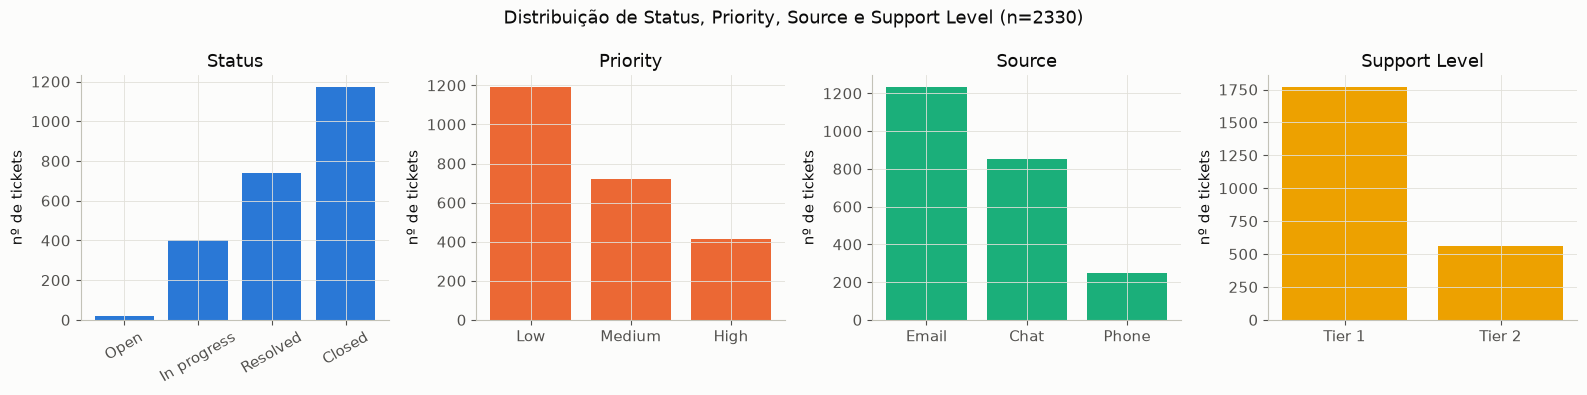

Status (%):
Status
Open            0.8
In progress    17.2
Resolved       31.7
Closed         50.3
Name: count, dtype: float64

Priority (%):
Priority
Low       51.2
Medium    31.0
High      17.9
Name: count, dtype: float64

Source (%):
Source
Email    53.0
Chat     36.5
Phone    10.6
Name: count, dtype: float64

Support Level (%):
Support Level
Tier 1    76.0
Tier 2    24.0
Name: count, dtype: float64


In [7]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

status_counts = df["Status"].value_counts().reindex(STATUS_ORDER)
axes[0].bar(status_counts.index.astype(str), status_counts.values, color=CATEGORICAL_PALETTE[0])
axes[0].set_title("Status")
axes[0].tick_params(axis="x", rotation=30)

priority_counts = df["Priority"].value_counts().reindex(PRIORITY_ORDER)
axes[1].bar(priority_counts.index.astype(str), priority_counts.values, color=CATEGORICAL_PALETTE[1])
axes[1].set_title("Priority")

source_counts = df["Source"].value_counts().reindex(SOURCE_ORDER)
axes[2].bar(source_counts.index.astype(str), source_counts.values, color=CATEGORICAL_PALETTE[2])
axes[2].set_title("Source")

support_counts = df["Support Level"].value_counts().reindex(SUPPORT_LEVEL_ORDER)
axes[3].bar(support_counts.index.astype(str), support_counts.values, color=CATEGORICAL_PALETTE[3])
axes[3].set_title("Support Level")

for ax in axes:
    ax.set_ylabel("nº de tickets")
fig.suptitle(f"Distribuição de Status, Priority, Source e Support Level (n={len(df)})")
plt.tight_layout()
plt.show()

print("Status (%):\n", (status_counts / len(df) * 100).round(1), sep="")
print("\nPriority (%):\n", (priority_counts / len(df) * 100).round(1), sep="")
print("\nSource (%):\n", (source_counts / len(df) * 100).round(1), sep="")
print("\nSupport Level (%):\n", (support_counts / len(df) * 100).round(1), sep="")

Apenas 18 tickets (~0.8%) ainda estão `Open` — a grande maioria já teve pelo menos uma interação. `Priority` e `Source` têm alguma concentração (`Low`/`Email` são os valores mais comuns) mas nenhuma classe é rara a ponto de inviabilizar análise por classe. `Support Level` é 76%/24% (`Tier 1`/`Tier 2`).

## 5. Qualidade das colunas categóricas: duplicatas de categoria e redundância

Duas checagens de qualidade específicas de dado categórico: (a) a mesma categoria aparece com grafias diferentes (ex.: variação de maiúscula/minúscula); (b) colunas que parecem independentes mas são, na prática, a mesma informação duplicada.

In [8]:
print("Topic — value_counts:")
print(df["Topic"].value_counts())

Topic — value_counts:
Topic
Product setup               630
Pricing and licensing       457
Feature request             417
Purchasing and invoicing    264
Bug report                  225
Other                       203
Pricing and Licensing        68
Training request             66
Name: count, dtype: int64


**Achado de qualidade:** `Topic` tem `"Pricing and licensing"` (457 tickets) e `"Pricing and Licensing"` (68 tickets) como categorias *separadas* — a única diferença é a capitalização de "Licensing". São claramente a mesma categoria duplicada por inconsistência de grafia, não dois tópicos distintos. Qualquer uso de `Topic` como feature categórica deve normalizar essa duplicata antes (ex.: `.str.lower()` ou um mapeamento explícito), senão o modelo trata como classes diferentes ~13% dos tickets que deveriam estar juntos.

In [9]:
print("nº de categorias distintas em Topic:", df["Topic"].nunique())
print("nº de categorias distintas após normalizar case:", df["Topic"].str.lower().nunique())

nº de categorias distintas em Topic: 8
nº de categorias distintas após normalizar case: 7


Checamos a mesma inconsistência (categoria duplicada por case) em todas as demais colunas categóricas — não se repete em nenhuma outra.

In [10]:
categorical_cols = ["Status", "Priority", "Source", "Agent Group", "Support Level", "Product group", "Country"]
for col in categorical_cols:
    n_raw = df[col].nunique()
    n_casefold = df[col].str.lower().nunique()
    print(f"{col}: {n_raw} categorias (raw), {n_casefold} (case-insensitive) -> {'OK' if n_raw == n_casefold else 'DUPLICATA DE CASE'}")

Status: 4 categorias (raw), 4 (case-insensitive) -> OK
Priority: 3 categorias (raw), 3 (case-insensitive) -> OK
Source: 3 categorias (raw), 3 (case-insensitive) -> OK
Agent Group: 2 categorias (raw), 2 (case-insensitive) -> OK
Support Level: 2 categorias (raw), 2 (case-insensitive) -> OK
Product group: 4 categorias (raw), 4 (case-insensitive) -> OK
Country: 12 categorias (raw), 12 (case-insensitive) -> OK


Agora a checagem de redundância entre colunas: `Agent Group` (`1st line support` / `2nd line support`) e `Support Level` (`Tier 1` / `Tier 2`) parecem descrever a mesma coisa com nomes diferentes.

In [11]:
print("Agent Group × Support Level:")
print(pd.crosstab(df["Agent Group"], df["Support Level"]))

Agent Group × Support Level:
Support Level     Tier 1  Tier 2
Agent Group                     
1st line support    1770       0
2nd line support       0     560


**Achado de qualidade:** `Agent Group` e `Support Level` são perfeitamente redundantes — `1st line support` corresponde exatamente a `Tier 1` e `2nd line support` a `Tier 2`, sem nenhuma célula fora da diagonal. É a mesma informação sob dois nomes; usar as duas como features independentes não adiciona sinal e pode confundir um modelo linear com colinearidade perfeita.

Vale checar também se `Agent Name` determina `Agent Group`/`Support Level` de forma 1:1, o que sugeriria que a divisão em tiers é uma propriedade do agente (fixa), não do ticket.

In [12]:
print("Agent Name × Agent Group:")
print(pd.crosstab(df["Agent Name"], df["Agent Group"]))

Agent Name × Agent Group:
Agent Group          1st line support  2nd line support
Agent Name                                             
Adolpho Messingham                  0               197
Bernard Beckley                   359                 0
Connor Danielovitch               347                 0
Heather Urry                        0               177
Kristos Westoll                   333                 0
Michele Whyatt                      0               186
Nicola Wane                       367                 0
Sheela Cutten                     364                 0


Confirmado: cada um dos 8 agentes atende exclusivamente `1st line support` ou `2nd line support`, nunca os dois. A divisão em tiers é uma característica fixa do agente, não algo que varia ticket a ticket — reforça que `Agent Group`/`Support Level` carregam a mesma informação que já está implícita em `Agent Name`.

## 6. Consistência temporal: ordem cronológica dos timestamps

Os cinco timestamps (`Created time`, `First response time`, `Resolution time`, `Close time`, mais os dois "Expected SLA to...") deveriam obedecer uma ordem lógica: um ticket é criado, depois recebe a primeira resposta, depois é resolvido, depois é fechado. Convertendo para datetime e comparando pares consecutivos, checamos se essa ordem é sempre respeitada.

In [13]:
for col in DATE_COLS:
    df[col] = pd.to_datetime(df[col])

print("intervalo de Created time:", df["Created time"].min(), "a", df["Created time"].max())

intervalo de Created time: 2023-01-02 00:58:36 a 2023-12-30 19:49:51


In [14]:
# Comparações com NaT resultam em False (não NaN) — o denominador de pares
# avaliáveis precisa ser calculado a partir dos dois campos originais, não do
# resultado booleano da comparação.
order_pairs = [
    ("First response time < Created time", "First response time", "Created time"),
    ("Resolution time < First response time", "Resolution time", "First response time"),
    ("Close time < Resolution time", "Close time", "Resolution time"),
]
order_checks = {}
for label, col_a, col_b in order_pairs:
    both_present = df[col_a].notna() & df[col_b].notna()
    mask = (df[col_a] < df[col_b]) & both_present
    order_checks[label] = mask
    print(f"{label}: {mask.sum()} violações (de {both_present.sum()} pares avaliáveis)")

First response time < Created time: 2 violações (de 2312 pares avaliáveis)
Resolution time < First response time: 18 violações (de 1912 pares avaliáveis)
Close time < Resolution time: 42 violações (de 1173 pares avaliáveis)


**Achado de qualidade:** existem violações reais de ordem cronológica, poucas mas presentes:

- 2 tickets com `First response time` anterior ao próprio `Created time`.
- 18 tickets com `Resolution time` anterior a `First response time`.
- 42 tickets com `Close time` anterior a `Resolution time`.

São inconsistências pequenas em proporção (< 2% em todos os casos), prováveis erros de entrada/registro dos timestamps — mas quem for calcular durações (tempo até primeira resposta, tempo de resolução) a partir desses campos deve tratar ou pelo menos filtrar essas linhas, senão a duração calculada fica negativa.

In [15]:
violation_mask = order_checks["Close time < Resolution time"] | order_checks["Resolution time < First response time"]
df.loc[violation_mask, ["Ticket ID", "Status", "Created time", "First response time", "Resolution time", "Close time"]].head(10)

,Ticket ID,Status,Created time,First response time,Resolution time,Close time
59,1082,Closed,2023-01-10 20:59:34,2023-01-10 21:00:37.516,2023-01-12 17:31:37.329,2023-01-12 14:16:45.427
172,1221,Resolved,2023-01-25 15:29:35,2023-01-25 23:19:34.934,2023-01-25 16:52:45.663,NaT
259,1331,Resolved,2023-02-07 18:37:55,2023-02-08 02:30:10.069,2023-02-07 23:03:12.985,NaT
268,1340,Closed,2023-02-08 04:38:57,2023-02-08 04:39:46.636,2023-02-09 03:39:36.342,2023-02-08 14:20:06.012
296,1379,Closed,2023-02-14 15:59:53,2023-02-14 16:11:38.158,2023-02-16 12:20:03.502,2023-02-15 19:54:53.134
346,1435,Closed,2023-02-21 19:30:54,2023-02-21 19:31:01.545,2023-02-22 21:05:04.604,2023-02-22 05:19:21.092
446,1552,Closed,2023-03-09 05:24:36,2023-03-09 06:07:16.582,2023-03-10 19:09:51.543,2023-03-10 17:01:09.153
517,1642,Closed,2023-03-20 16:27:35,2023-03-20 16:28:37.582,2023-03-22 03:58:27.124,2023-03-21 11:47:51.601
520,1645,Closed,2023-03-20 18:36:23,2023-03-20 19:32:38.909,2023-03-20 19:28:53.303,2023-03-25 11:04:25.169
533,1658,Closed,2023-03-23 13:58:43,2023-03-23 14:27:28.381,2023-03-25 10:50:46.513,2023-03-24 10:57:00.137


## 7. Consistência das colunas de SLA vs. os timestamps reais

`SLA For first response` e `SLA For Resolution` são rótulos categóricos (`"Within SLA"` / `"SLA Violated"`) que deveriam ser totalmente derivados da comparação entre o timestamp real e o `Expected SLA to...` correspondente. Recalculamos essa comparação a partir dos timestamps e cruzamos com o rótulo já presente no dataset.

In [16]:
has_first_response = df["First response time"].notna()
actual_late_first_response = df.loc[has_first_response, "First response time"] > df.loc[has_first_response, "Expected SLA to first response"]
print("Recalculado × rótulo original (SLA For first response):")
print(pd.crosstab(actual_late_first_response.map({True: "atrasado (calculado)", False: "no prazo (calculado)"}),
                   df.loc[has_first_response, "SLA For first response"]))

Recalculado × rótulo original (SLA For first response):
SLA For first response  SLA Violated  Within SLA
row_0                                           
atrasado (calculado)             279           0
no prazo (calculado)              14        2019


**Achado de qualidade:** 14 tickets estão rotulados `"SLA Violated"` em `SLA For first response`, mas pelo timestamp real a primeira resposta ocorreu *dentro* do prazo esperado. É uma pequena inconsistência (14 de 2312 tickets com primeira resposta, ~0.6%) entre o rótulo pré-calculado e os dados brutos — sinal de que o rótulo não deve ser tomado como automaticamente confiável sem essa checagem cruzada.

In [17]:
has_resolution = df["Resolution time"].notna()
actual_late_resolution = df.loc[has_resolution, "Resolution time"] > df.loc[has_resolution, "Expected SLA to resolve"]
print("Recalculado × rótulo original (SLA For Resolution):")
print(pd.crosstab(actual_late_resolution.map({True: "atrasado (calculado)", False: "no prazo (calculado)"}),
                   df.loc[has_resolution, "SLA For Resolution"]))

Recalculado × rótulo original (SLA For Resolution):
SLA For Resolution    SLA Violated  Within SLA
row_0                                         
atrasado (calculado)           366           0
no prazo (calculado)             0        1546


Já `SLA For Resolution` é 100% consistente com os timestamps — nenhuma discrepância entre o rótulo e o cálculo direto. A inconsistência da seção anterior é específica de `SLA For first response`.

## 8. Geolocalização: granularidade real de `Latitude`/`Longitude`

Há coordenadas por ticket, mas antes de tratá-las como um atributo granular (por ticket) vale confirmar se de fato variam ticket a ticket ou se são uma constante por `Country`.

In [18]:
coords_per_country = df.groupby("Country")[["Latitude", "Longitude"]].nunique()
coords_per_country

,Latitude,Longitude
Country,,
Austria,1,1
Bulgaria,1,1
Czech Republic,1,1
France,1,1
Germany,1,1
Greece,1,1
Italy,1,1
Poland,1,1
Republic of Ireland,1,1


**Achado de qualidade:** todo país tem exatamente 1 par único de `(Latitude, Longitude)` — ou seja, essas colunas não são geolocalização real por ticket, são um centróide fixo por país repetido em todas as suas linhas. Servem para um mapa agregado por país, mas não trazem nenhuma informação além do que já está em `Country`; não usar como feature contínua de localização.

In [19]:
print(f"nº de países: {df['Country'].nunique()}")
df["Country"].value_counts()

nº de países: 12


Country
Germany                306
Italy                  303
Poland                 287
United Kingdom         283
Slovenia               159
France                 158
Republic of Ireland    148
Austria                144
Greece                 144
Czech Republic         134
Spain                  133
Bulgaria               131
Name: count, dtype: int64

## 9. Resumo dos principais achados

- **Schema e escopo diferentes do pipeline principal:** 2.330 tickets, 22 colunas, chave explícita `Ticket ID` (única, mas não contígua — este arquivo é uma amostra de uma base maior, não o universo completo).
- **Sem duplicatas:** nenhuma linha nem `Ticket ID` duplicados.
- **Nulos 100% estruturais:** `Close time`, `Resolution time`, `First response time`/`Agent interactions` e `Survey results` são nulos exatamente quando o `Status` do ticket ainda não alcançou aquela etapa (ou, no caso de `Survey results`, quando o ticket não foi fechado) — nenhuma lacuna aleatória.
- **Duplicata de categoria:** `Topic` tem `"Pricing and licensing"` e `"Pricing and Licensing"` como categorias separadas por diferença de capitalização (juntas, ~13% dos tickets) — precisa normalização antes de uso como feature.
- **Colunas redundantes:** `Agent Group` e `Support Level` codificam exatamente a mesma partição (`1st line support` ≡ `Tier 1`, `2nd line support` ≡ `Tier 2`), e essa partição por sua vez é uma propriedade fixa de cada `Agent Name` (8 agentes, cada um exclusivo de um grupo) — as três colunas juntas carregam só 1 bit de informação nova.
- **Inconsistências cronológicas pontuais:** 2 tickets com primeira resposta antes da criação, 18 com resolução antes da primeira resposta, 42 com fechamento antes da resolução — poucos casos (<2%), mas exigem filtro/tratamento antes de calcular durações.
- **SLA pré-calculado majoritariamente confiável, com uma falha pequena:** `SLA For Resolution` é 100% consistente com os timestamps; `SLA For first response` tem 14 tickets (~0.6%) rotulados como violados que, pelo timestamp, estavam no prazo.
- **Geolocalização é granularidade de país, não de ticket:** `Latitude`/`Longitude` são um centróide fixo por `Country` (12 países) — não usar como feature contínua independente de `Country`.

**Conclusão:** dataset estruturalmente limpo (sem duplicatas, nulos todos explicáveis), mas com problemas de qualidade concretos e localizados — categoria duplicada em `Topic`, colunas redundantes em `Agent Group`/`Support Level`, e uma minoria de linhas com timestamps/rótulos de SLA inconsistentes. Qualquer uso para modelagem deve corrigir a duplicata de `Topic`, escolher uma única coluna entre `Agent Group`/`Support Level`/`Agent Name` para não introduzir colinearidade, e decidir se as linhas com violação de ordem cronológica são filtradas ou mantidas.